<img src="Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Santiago Boente

En este trabajo práctico tuvimos como finalidad analizar múltiples senoidales a las que se le agrega una pequeña desintonía para analizar como estas afectan al espectro visualizado. Mostrándonos el fenómeno de desparramo espectral. 

Para realizar este trabajo tomaremos como parámetros:

Senoidal de frecuencia f0 = k0∗fS/N = k0*$\Delta$f

Potencia normalizada, es decir energía (o varianza) unitaria.

Para distintas desintonías k0: 

N / 4 

N / 4 + 0.25

N / 4 + 0.5

Para k0 = N/4:

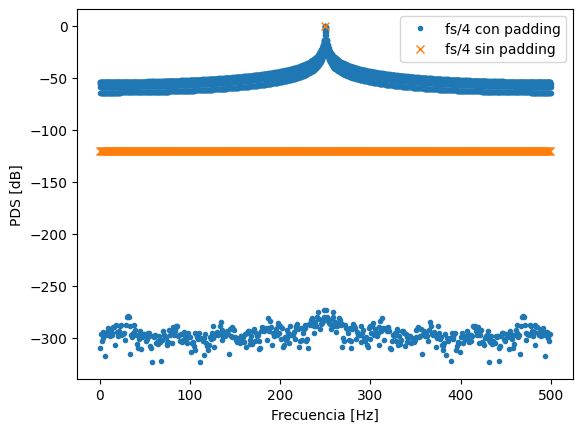

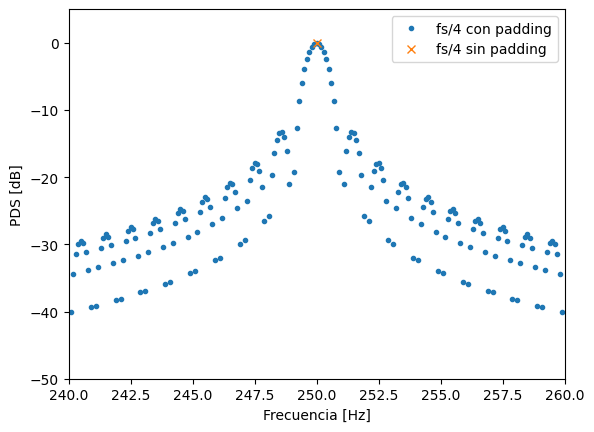

1.0000000000000002


In [5]:
import numpy as np
import matplotlib.pyplot as plt

"vmax: Amplitud maxima , dc: valor medio , ff: frecuencia, ph: fase en radianes , nn: numero de muestras , fs: frecuencia de muestreo" 

A = np.sqrt(2)
N = 1000
k0 = N/4
fs = 1000
f0 = k0 * fs/N

def mi_funcion_sen(vmax, dc , ff , ph , nn , fs):
    
    ts = 1/fs
    tt = np.arange(0, nn, 1)*ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx 
"tt: vector de tiempo , xx: vector de señal"
    
tt, xx = mi_funcion_sen(A , 0 , f0 , 0 , N , fs)


X1 = np.fft.fft(xx)/N
P1 = 2*np.abs(X1)**2
P1_dB = 10*np.log10(P1[:N//2] + 1e-12)

freq1 = np.arange(0 , fs/2, fs/N)


#aca hacemos zero padding
zz = np.zeros_like(xx)
zzzz = np.tile(zz, 9)
xxzz = np.concatenate((xx, zzzz), axis = None)

M = len(xxzz)
XX = np.fft.fft(xxzz)/N
XX_mod = 2 * (np.abs(XX[:M//2])**2)

#paso a dB
M = len(xxzz)
XX_f0 = 10 * np.log10(XX_mod)

freq = np.arange(0, fs/2, fs/(M))

plt.figure()
plt.plot(freq, XX_f0, marker = 'o', label = 'fs/4 con padding', linestyle = '', markersize=3)
plt.plot(freq1, P1_dB, marker = 'x', label = 'fs/4 sin padding', linestyle = '')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [dB]")
plt.legend()
plt.show()

plt.figure()
plt.xlim(240, 260)
plt.ylim(-50, 5)
plt.plot(freq, XX_f0, marker = 'o', label = 'fs/4 con padding', linestyle = '', markersize=3)
plt.plot(freq1, P1_dB, marker = 'x', label = 'fs/4 sin padding', linestyle = '')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [dB]")
plt.legend()
plt.show()

print(np.mean(xx**2))

En este caso podemos apreciar que para N/4, la frecuencia f0 es múltiplo de $\Delta$f. Entonces en la FFT se puede apreciar que la senoidal se encuentra dentro de la ventana de observación. Por lo que aparece el espectro concentrado en un único bin y se aprecia el punto de energía máxima en 250. Al agregar zero-padding se puede visualizar mejor la forma del espectro.

Para k0 = N/4 + 0.25

0.9989999999999996


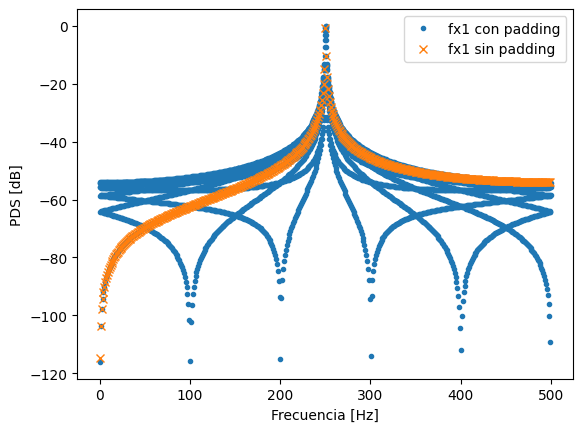

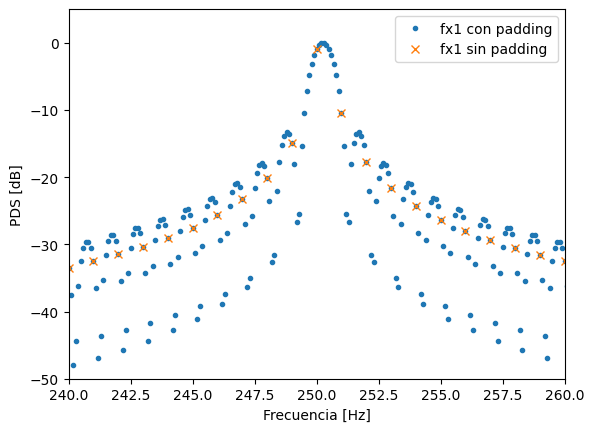

In [6]:
k0 = N/4 + 0.25
fx1 = k0 * fs/N

tt, xx = mi_funcion_sen(A , 0 , fx1 , 0 , N , fs)

#sin padding
X1 = np.fft.fft(xx)/N
P1 = 2*np.abs(X1)**2
P1_dB = 10*np.log10(P1[:N//2] + 1e-12)

freq1 = np.arange(0 , fs/2, fs/N)

#con padding
zz = np.zeros_like(xx)
zzzz = np.tile(zz, 9)
xxzz = np.concatenate((xx, zzzz), axis = None)

M = len(xxzz)
XX = np.fft.fft(xxzz)/N
XX_mod = 2 * (np.abs(XX[:M//2])**2)

#paso a dBM = len(xxzz)
XX_fx1 = 10 * np.log10(XX_mod)


freq = np.arange(0, fs/2, fs/(M))

plt.figure()
plt.plot(freq, XX_fx1, marker = 'o', label = 'fx1 con padding', linestyle = '', markersize=3)
plt.plot(freq1, P1_dB, marker = 'x', label = 'fx1 sin padding', linestyle = '')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [dB]")
plt.legend()

plt.figure()
plt.xlim(240, 260)
plt.ylim(-50, 5)
plt.plot(freq, XX_fx1, marker = 'o', label = 'fx1 con padding', linestyle = '', markersize=3)
plt.plot(freq1, P1_dB, marker = 'x', label = 'fx1 sin padding', linestyle = '')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [dB]")
plt.legend()

print(np.mean(xx**2))

En este caso podemos observar que para n/4 + 0.25, la frecuencia f0 no es múltiplo de $\Delta$f, por lo que hay desparramo espectral y no podemos ver con claridad dónde se encuentra el máximo del espectro. Al agregarle zero padding, podemos obtener una mejor visualización de dónde se encuentra el máximo, que debería estar en 250.25 pero no se aprecia al no ser múltiplo de 0.1. 

Para k0 = N/4 + 0.5

1.0000000000000004


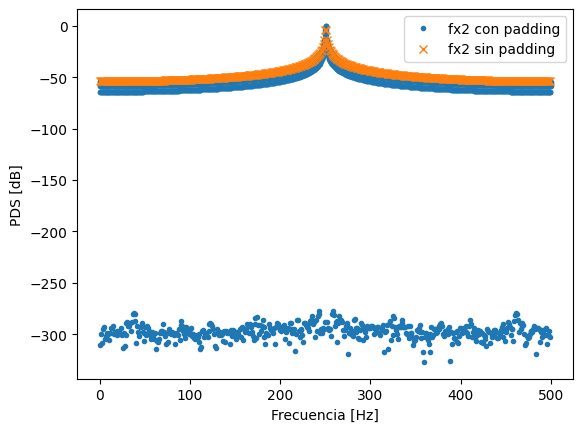

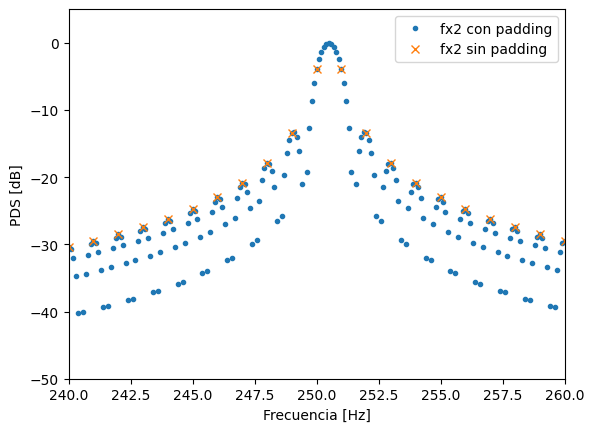

In [7]:
k0 = N/4 + 0.5
fx2 = k0 * fs/N

tt, xx = mi_funcion_sen(A , 0 , fx2 , 0 , N , fs)

#sin padding
X1 = np.fft.fft(xx)/N
P1 = 2*np.abs(X1)**2
P1_dB = 10*np.log10(P1[:N//2] + 1e-12)

freq1 = np.arange(0 , fs/2, fs/N)

zz = np.zeros_like(xx)
zzzz = np.tile(zz, 9)
xxzz = np.concatenate((xx, zzzz), axis = None)

#con padding
M = len(xxzz)
XX = np.fft.fft(xxzz)/N
XX_mod = 2 * (np.abs(XX[:M//2])**2)

#paso a dBM = len(xxzz)
XX_fx2 = 10 * np.log10(XX_mod)


freq = np.arange(0, fs/2, fs/(M))

plt.figure()
plt.plot(freq, XX_fx2, marker = 'o', label = 'fx2 con padding', linestyle = '', markersize=3)
plt.plot(freq1, P1_dB, marker = 'x', label = 'fx2 sin padding', linestyle = '')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [dB]")
plt.legend()

plt.figure()
plt.xlim(240, 260)
plt.ylim(-50, 5)
plt.plot(freq, XX_fx2, marker = 'o', label = 'fx2 con padding', linestyle = '', markersize=3)
plt.plot(freq1, P1_dB, marker = 'x', label = 'fx2 sin padding', linestyle = '')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [dB]")
plt.legend()

print(np.mean(xx**2))

En este caso podemos observar que la frecuencia queda exactamente entre 2 bins originales con una amplitud casi igual por lo que la energía se distribuye entre esos bins. Al hacer zero-padding se puede observar que el máximo de energía está en 250.5, que es en el medio de los 2 bins.

En este trabajo práctico aprendimos cómo una frecuencia que no coincide con uno de los bins disponibles genera desparramo espectral y como se visualiza. Además, vimos que al usar zero-padding se nos permite tener una visualización de la ubicación aproximada de la frecuencia de la senoidal y el efecto del desparramo espectral.